In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import ee
ee.Authenticate()
ee.Initialize(project = 'analog-foundry-466522-c7')

## Machine Learning Models

While most of the mll algorhthms available in SKLEARN(and several other compatible libraries, such as LightGbM) are commonly used for regression and tabular classification, there is no inherent reason why they cannot be effectively applied to time series forecasting.

From a theoretical perspective, these approaches may not necessarily satisfy the conditions required for a regression model. Time series data typically exhibit some degree of autocorrelation, meaning that data observed at time t is related to previous data (t-1) and possibly even more. A typical regression model typically assumes independent observations, so they mmay not be well suited to capture autocorrelation. However, it is still possible to use lagged series as predictors and allow the model to learn from existing autocorrelation or other patterns.

Sklearn offers a wide range of regression models, ranging from basic linear regression to highly advanced boosted trees. Along with this, hyperparameter tuning and implementing cross-validation are common practices to ensure better model generality and accuracy.

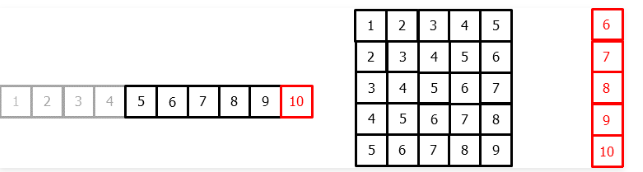

Since we are treating time series forecasting as a regression problem, we would need to have a predictor. Here, we assume that we only have a univariate series with 5 days

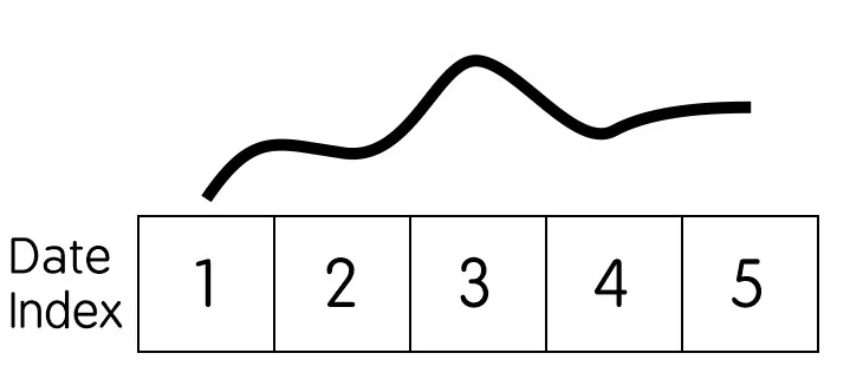



At the beginning, we only have data up to day 5. Let’s say we use the previous 3 days as the predictor. This means we are using up to 3 lagged data. To predict day 4, we use data from days 1 to 3. To predict day 5, we use data from days 2 to 4. Then, to predict day 6, we use data from days 3 to 5.

In tabular terms, we can write the predictor and the response as follows. We label yesterday’s data as Xt-1, two days ago as Xt-2, and three days ago as Xt-3.

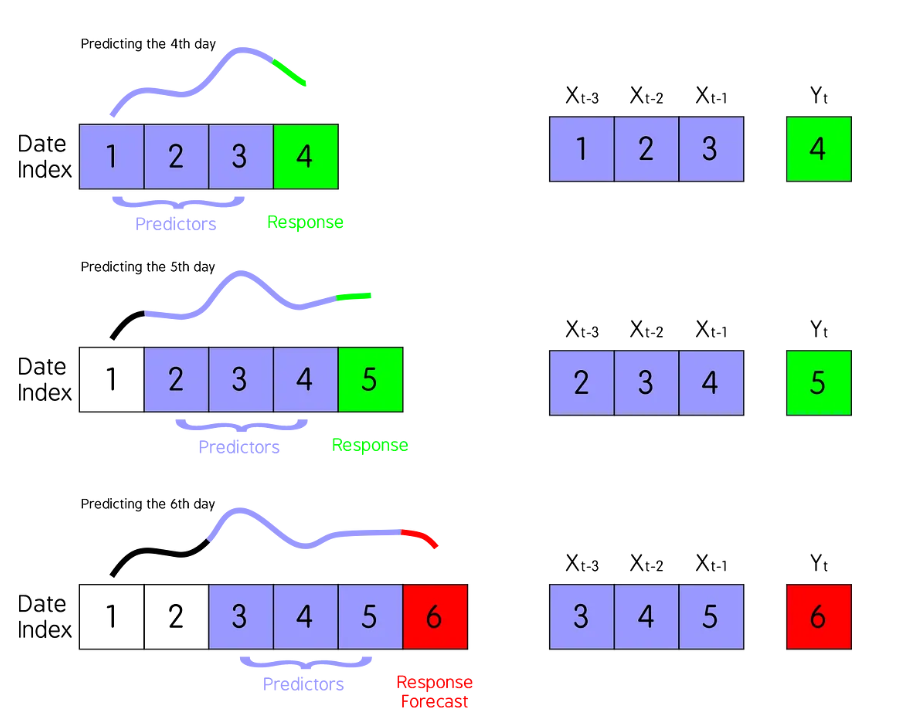

We have established a way to predict one step into the future. How about predicting 2 days ahead? Or 3? This is where we introduce the concept of recursive prediction. In short, to predict day 7, we make a prediction for day 6 and then use that predicted value as our Xt-1. Essentially, we are treating the previous prediction as a new predictor for the future. We do this as often as necessary and it is quite efficient.


image.png


However, there are several problems with this approach. If we want to predict far into the future, the model may give a relatively flat prediction. It may also introduce new bias, as the 6th predicted data may be far from the actual value.

Again, it is possible to include exogenous variables in the model. Keep in mind that to predict the 6th data, we must also provide the exogenous variable for that same index.

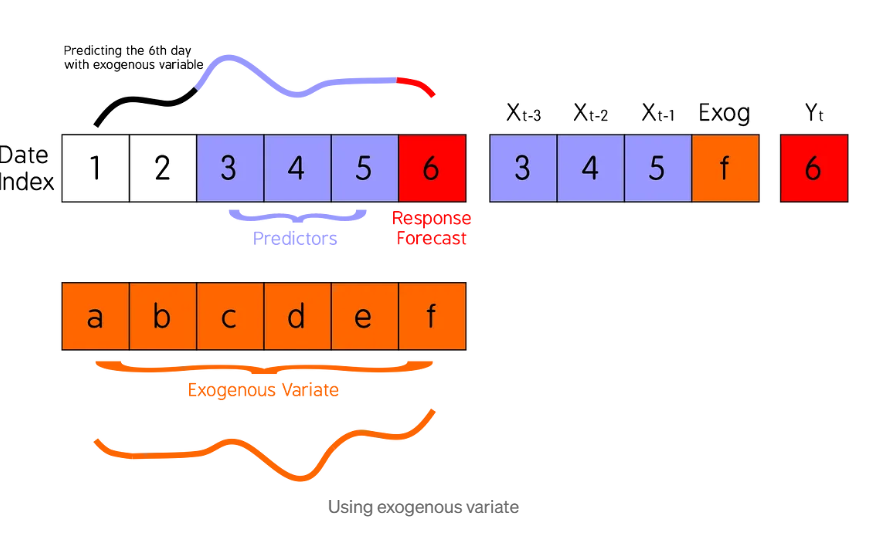

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import geemap
import datetime

In [4]:
italy = ee.Geometry.Polygon([[[8.290016551188252, 45.79137351065613],
          [8.290016551188252, 45.0588767633071],
          [10.168678660563252, 45.0588767633071],
          [10.168678660563252, 45.79137351065613]]])

In [5]:
startDate = '2023-01-01'
endDate = '2023-12-31'

In [6]:
#Coletando as imagens
s5p_no = ee.ImageCollection('COPERNICUS/S5P/NRTI/L3_NO2').filterDate(startDate, endDate).filterBounds(italy).select('NO2_column_number_density')

In [7]:
#Extraindo a serie e convertendo em um dataframe
def extract_time_series(image_collection, column):
  def reduce_region_func(image):
    reduced_image = image.reduceRegion(
        reducer = ee.Reducer.sum(),
        geometry = italy,
        scale = 1000,
        maxPixels = 1e13,
    )
    return image.set(reduced_image)
  reduced_collection = image_collection.map(reduce_region_func)
  time_series_time = image_collection.aggregate_array('system:time_start').getInfo()
  time_series_values = reduced_collection.aggregate_array(column).getInfo()
  #Create a dataframe
  time_series_df = pd.DataFrame({'time_start': time_series_time, 'value' : time_series_values})
  time_series_df['time_start'] = pd.to_datetime(time_series_df['time_start'], unit = 'ms')
  time_series_df.set_index('time_start', inplace = True)
  return time_series_df

no2_time_series = extract_time_series(s5p_no, 'NO2_column_number_density')

In [8]:
no2_time_series.index = no2_time_series.index.strftime('%Y-%m-%d')

In [9]:
no2_time_series_grouped = no2_time_series.groupby(no2_time_series.index).sum()

In [10]:
df = pd.DataFrame(columns=['NO2'])
df['NO2'] = no2_time_series_grouped['value']

In [11]:
df.dropna(axis=0, inplace=True)

In [12]:
df

,NO2
time_start,
2023-01-01,0.000000
2023-01-02,0.000000
2023-01-03,0.000000
2023-01-04,0.761993
2023-01-05,2.932946
...,...
2023-12-26,0.186080
2023-12-27,0.479616
2023-12-28,0.018625


In [13]:
# vamos transformar em um dataset junto ao shift
df['NO2_shift1'] = df['NO2'].shift(1)
df['NO2_shift2'] = df['NO2'].shift(2)
df['NO2_shift3'] = df['NO2'].shift(3)
df['NO2_shift4'] = df['NO2'].shift(4)
df['NO2_shift5'] = df['NO2'].shift(5)
df['NO2_shift6'] = df['NO2'].shift(6)
df['NO2_shift7'] = df['NO2'].shift(7)

In [14]:
#wE WILL REMOVE THE DAYS WHERE WE DO NOT HAVE ALL THE FULL SHIFTS
df.dropna(axis = 0, inplace = True)

In [15]:
df

,NO2,NO2_shift1,NO2_shift2,NO2_shift3,NO2_shift4,NO2_shift5,NO2_shift6,NO2_shift7
time_start,,,,,,,,
2023-01-08,0.000000,0.159310,0.298960,2.932946,0.761993,0.000000,0.000000,0.000000
2023-01-09,2.240540,0.000000,0.159310,0.298960,2.932946,0.761993,0.000000,0.000000
2023-01-10,2.271606,2.240540,0.000000,0.159310,0.298960,2.932946,0.761993,0.000000
2023-01-11,0.060257,2.271606,2.240540,0.000000,0.159310,0.298960,2.932946,0.761993
2023-01-12,4.698081,0.060257,2.271606,2.240540,0.000000,0.159310,0.298960,2.932946
...,...,...,...,...,...,...,...,...
2023-12-26,0.186080,4.018553,2.851075,1.642095,1.187997,1.675884,4.314245,5.597540
2023-12-27,0.479616,0.186080,4.018553,2.851075,1.642095,1.187997,1.675884,4.314245
2023-12-28,0.018625,0.479616,0.186080,4.018553,2.851075,1.642095,1.187997,1.675884


In [16]:
X = df[['NO2', 'NO2_shift1', 'NO2_shift2', 'NO2_shift3', 'NO2_shift4', 'NO2_shift5', 'NO2_shift6']]

y = df['NO2_shift7']

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=False)

In [18]:
from sklearn.tree import DecisionTreeRegressor
classifier = DecisionTreeRegressor(random_state=42)
classifier.fit(X_train, y_train)

from sklearn.metrics import r2_score
print(r2_score(list(y_test), list(classifier.predict(X_test))))

-0.9494464523178128


In [19]:
from sklearn.model_selection import GridSearchCV

my_dt = GridSearchCV(DecisionTreeRegressor(random_state=42),
                 {'min_samples_split': list(range(20,50, 2)),
                 'max_features': [0.6, 0.7, 0.8, 0.9, 1.]},
                scoring = 'r2', n_jobs = -1)

my_dt.fit(X_train, y_train)
print(r2_score(list(y_test), list(my_dt.predict(X_test))))

-0.10279064992595943


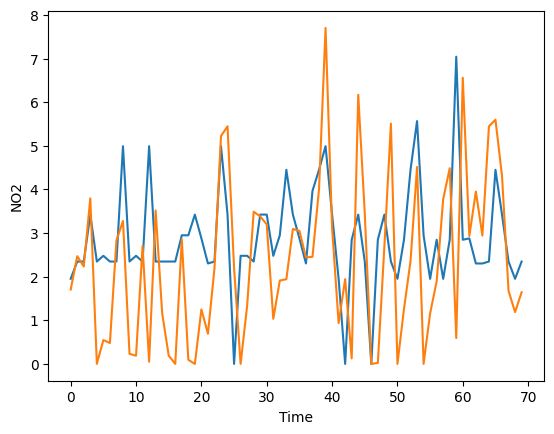

In [20]:
fcst = my_dt.predict(X_test)

plt.plot(list(fcst))
plt.plot(list(y_test))
plt.ylabel('NO2')
plt.xlabel('Time')
plt.show()

## Recursive multi-step forecasting
Let's now use recursive multistep forecasting. To do this, we will select a point and obtain LST time series data:


In [21]:
geometry_test = ee.Geometry.Point([-55.05744298464864, -13.547299531642683])

In [22]:
modisLst = ee.ImageCollection('MODIS/061/MOD11A1').filterDate(startDate, endDate).filterBounds(geometry_test).select('LST_Day_1km')

In [23]:
#Vamos pegar os meses
months = ee.List.sequence(1,12)
#vamos pegar os anos agora
years = ee.List.sequence(2016, 2024)

In [24]:
def monthly(collection):
  img_coll = ee.ImageCollection([])
  for y in years.getInfo():
    for m in months.getInfo():
      filtered = collection.filter(ee.Filter.calendarRange(y, y, 'year')).filter(ee.Filter.calendarRange(m, m, 'month'))
      filtered = filtered.median()
      img_coll = img_coll.merge(filtered.set('year', y).set('month', m).set('system:time_start', ee.Date.fromYMD(y, m, 1).getInfo()['value']))
  return img_coll

In [25]:
modisList = monthly(modisLst)

In [26]:
def meanLST(image):
  image = ee.Image(image)
  meanDict = image.reduceRegion(reducer = ee.Reducer.mean().setOutputs(['LST_Day_1km']),
  geometry = geometry_test,
  scale = image.projection().nominalScale().getInfo(),
  maxPixels = 1e13,
  bestEffort = True);
  return meanDict.get('LST_Day_1km').getInfo()

In [27]:
listOfImages_modis = modisLst.select('LST_Day_1km').toList(modisLst.size())
lst_coll = []

for i in range(listOfImages_modis.length().getInfo()):
    image = ee.Image(listOfImages_modis.get(i-1))
    temp_lst = meanLST(image)
    lst_coll.append(temp_lst)

In [28]:
#Convertendo a lista em um dataframe
dates = np.array(modisLst.aggregate_array('system:time_start').getInfo())
day = [datetime.datetime.fromtimestamp(i/1000).strftime('%Y-%m-%d') for i in (dates)]

In [29]:
lst_df = pd.DataFrame(lst_coll, index = day, columns = ['LST'])
lst_df.index = pd.to_datetime(lst_df.index)
lst_df.sort_index(ascending = True, inplace = True)

In [30]:
lst_df

,LST
2023-01-01,NaN
2023-01-02,14800.0
2023-01-03,NaN
2023-01-04,NaN
2023-01-05,NaN
...,...
2023-12-26,15023.0
2023-12-27,NaN
2023-12-28,15185.0
2023-12-29,NaN


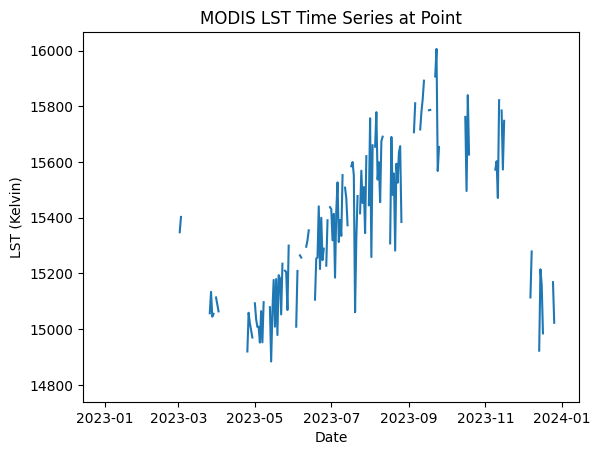

In [31]:
#Temos tambem a serie temporal
plt.plot(lst_df['LST'])
plt.xlabel('Date')
plt.ylabel('LST (Kelvin)')
plt.title('MODIS LST Time Series at Point')
plt.show()

In [55]:
steps = 24
data_train = lst_df[:-steps]
data_test  = lst_df[-steps:]

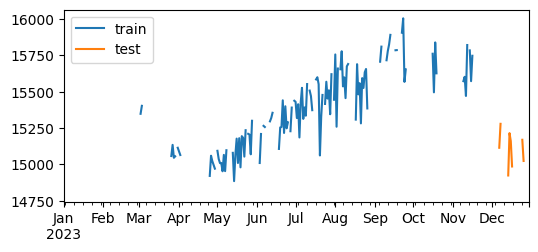

In [33]:
fig, ax = plt.subplots(figsize=(6, 2.5))
data_train['LST'].plot(ax=ax, label='train')
data_test['LST'].plot(ax=ax, label='test')
ax.legend();

In [34]:
#Vamos implementar skforest implementation
!pip install skforecast

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 851.4/851.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 32.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 28.7 MB/s eta 0:00:00


In [35]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import skforecast
from skforecast.recursive import ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.plot import plot_prediction_intervals
from sklearn.linear_model import Ridge

In [36]:
forecaster = ForecasterRecursive(
    regressor = RandomForestRegressor(random_state = 42),
    lags = 12,
)

# Handle missing values by dropping rows with NaN before fitting
data_train_cleaned = data_train['LST'].dropna()

# Reindex to a daily frequency to ensure the index has a frequency
data_train_cleaned = data_train_cleaned.asfreq('D')

# Fill remaining NaNs after reindexing
data_train_cleaned = data_train_cleaned.fillna(method='ffill')

forecaster.fit(y = data_train_cleaned)
forecaster

/tmp/ipython-input-287342405.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_train_cleaned = data_train_cleaned.fillna(method='ffill')


=================== 
ForecasterRecursive 
=================== 
Regressor: RandomForestRegressor 
Lags: [ 1  2  3  4  5  6  7  8  9 10 11 12] 
Window features: None 
Window size: 12 
Series name: LST 
Exogenous included: False 
Exogenous names: None 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Training range: [Timestamp('2023-01-02 00:00:00'), Timestamp('2023-12-03 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: D 
Regressor parameters: 
    {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth':
    None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None,
    'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2,
    'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100,
    'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0,
    'warm_start': False} 
fit_kwargs: {} 
Creation date: 2025-08-20 12:49:15 
Last fit date: 2025-08-20 12:49:15 
Skforecast version: 0.17.0 
Python version: 3.12.11 
Forecaster id: None

In [37]:
#Vamos aplicar a predição em 24 etapas no futuro
steps = 24
predictions = forecaster.predict(steps = steps)

In [38]:
predictions.index = data_test.index

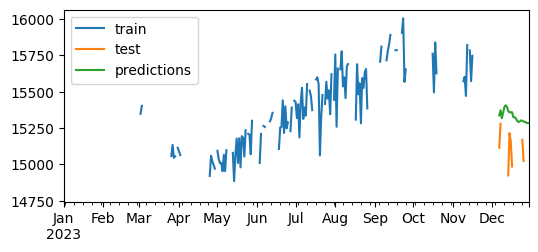

In [39]:
fig, ax = plt.subplots(figsize=(6, 2.5))
data_train['LST'].plot(ax=ax, label='train')
data_test['LST'].plot(ax=ax, label='test')
predictions.plot(ax=ax, label='predictions')
ax.legend();

In [40]:
# Remove rows with NaN values from data_test['LST'] and align predictions
data_test_cleaned = data_test['LST'].dropna()
predictions_aligned = predictions[data_test_cleaned.index]

error_mse = mean_squared_error(
                y_true = data_test_cleaned,
                y_pred = predictions_aligned
            )
print(f"Test error (MSE): {error_mse}")

Test error (MSE): 63561.43524711116


In [41]:
importance = forecaster.get_feature_importances()
importance.head(10)

,feature,importance
0,lag_1,0.495089
1,lag_2,0.159223
4,lag_5,0.130150
6,lag_7,0.058295
3,lag_4,0.056894
2,lag_3,0.040185
11,lag_12,0.015306
5,lag_6,0.011355
7,lag_8,0.009320
9,lag_10,0.008862


## Probabilistic forecasting
Probabilistic forecasting, as opposed to point forecasting, is a family of techniques that allows the preiction of the expected distribution of the outcome rather than a single future value. This tpe of forecasting provides much richer information because it allows the creation of prediction intervals, the range of likely values where the true value might fall. More formally, a prediction interval define the range whihin which the true value of the response variable is expected to be found with a given probability

In [42]:
forecaster = ForecasterRecursive(
                 regressor = Ridge(alpha=0.1, random_state=765),
                 lags      = 12
             )

# Handle missing values by dropping rows with NaN before fitting
data_train_cleaned = data_train['LST'].dropna()

# Reindex to a daily frequency to ensure the index has a frequency
data_train_cleaned = data_train_cleaned.asfreq('D')

# Fill remaining NaNs after reindexing (although should be minimal after dropna and asfreq)
data_train_cleaned = data_train_cleaned.fillna(method='ffill')


forecaster.fit(y=data_train_cleaned, store_in_sample_residuals=True)

/tmp/ipython-input-889763444.py:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_train_cleaned = data_train_cleaned.fillna(method='ffill')


In [43]:
predictions = forecaster.predict_interval(
                steps    = steps,
                interval = [5, 95],
                method   = 'bootstrapping',
                n_boot   = 500
              )

In [44]:
predictions.index = data_test.index
predictions

,pred,lower_bound,upper_bound
2023-12-07,15206.595974,15062.728642,15375.107786
2023-12-08,15267.442658,15090.194903,15379.800705
2023-12-09,15295.481198,15085.319673,15425.501717
2023-12-10,15236.887456,15072.552747,15394.992946
2023-12-11,15254.868517,15065.789694,15407.709679
2023-12-12,15300.199955,15073.394301,15467.337248
2023-12-13,15307.148169,15096.958661,15474.585947
2023-12-14,15273.105533,15071.601910,15474.743450
2023-12-15,15267.984938,15058.595223,15482.161799
2023-12-16,15298.418021,15090.454536,15582.792617


In [47]:
import matplotlib.pyplot as plt
plt.style.use('fivethirteight')
plt.rcParams['lines.linewidht'] = 1.5
plt.rcParams['font.size'] = 10

OSError: 'fivethirteight' is not a valid package style, path of style file, URL of style file, or library style name (library styles are listed in `style.available`)

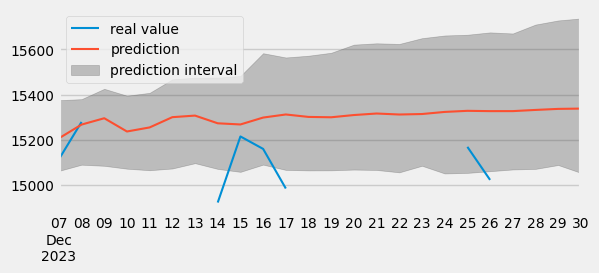

In [46]:
fig, ax = plt.subplots(figsize=(6, 2.5))
plot_prediction_intervals(
    predictions     = predictions,
    y_true          = data_test,
    target_variable = "LST",
    ax              = ax
)

## Forecasting with exogenous varibles

We can add exogenous variables to the moddelo. Let's use the month index as an exogenous variable

In [46]:
lst_df['month'] = lst_df.index.month

In [49]:
lst_df

,LST
2023-01-01,NaN
2023-01-02,14800.0
2023-01-03,NaN
2023-01-04,NaN
2023-01-05,NaN
...,...
2023-12-26,15023.0
2023-12-27,NaN
2023-12-28,15185.0
2023-12-29,NaN


In [52]:
lst_df.index = pd.to_datetime(lst_df.index)
# Resample to monthly frequency and take the mean value for each month
lst_df = lst_df.resample('MS').mean()
lst_df.index.freq = 'MS'

In [48]:
#Vamos usar o xgboost para uma uma predição recursiva
from xgboost import XGBRegressor

In [58]:
forecaster = ForecasterRecursive(
                 regressor = XGBRegressor(random_state=42),
                 lags      = 12
             )

# Handle missing values in y and exog before fitting
y_train_cleaned = data_train['LST'].ffill()
exog_train_cleaned = data_train['month'].ffill()

forecaster.fit(y=y_train_cleaned, exog=exog_train_cleaned)

KeyError: 'month'

In [ ]:
predictions = forecaster.predict(steps = steps, exog = data_test['month'])

In [ ]:
fig, ax = plt.subplots(figsize=(6, 2.5))
data_train['LST'].plot(ax=ax, label='train')
data_test['LST'].plot(ax=ax, label='test')
predictions.plot(ax=ax, label='predictions')
ax.legend();

## Prophet

Prophet is a open-source tool released by facebook data science team that produces time-series forecasting data based on an additive model where a non-linear trends adjusts for seasonality and holiday effects. The design priciples allow parameter adjustments without much knowledge of the underlying model , making the method applicable to teams with less statistical expertise

Prophet is designed to forecast univariate time series data based on decomposition components (trend+seasonality+holidays). Prophet is easy to use and automatically finds a good set of hyperparameters in an effort to make skillful predictions for trending data without requiring special domain knowledge.

Prophet also provides easy and customizable ways to tune the hyperparameters, even for someone who has no experience in forecasting models to make skillful predictions for a variety of problems in a business scenario.

Prophet is particularly well-suited for business forecasting applications and has gained popularity due to its ease of use and effectiveness in handling a wide range of time series data. As with all tools, keep in mind that while Prophet is powerful, the choice of forecasting method depends on the specific characteristics of the data and the goals of the analysis. In general, Prophet is not guaranteed to perform better than other models. However, Prophet does come with some useful features, for example, reflecting pre- and post-COVID seasonality changes or treating lockdowns as one-off holidays.

In [59]:
!pip install prophet

In [60]:
train_prophet = pd.DataFrame()
train_prophet['ds'] = data_train.index
train_prophet['y'] = data_train.LST.values

In [61]:
from prophet import Prophet


model = Prophet( yearly_seasonality=True, seasonality_mode = 'additive')
model.fit(train_prophet)

ValueError: Dataframe has less than 2 non-NaN rows.

In [ ]:
future = model.make_future_dataframe(periods = 24, freq = 'M')

In [ ]:
future

In [ ]:
forecast = model.predict(future)

In [ ]:
forecast.index = lst_df.index

In [ ]:
forecast.iloc[-24:][['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

In [62]:
#Comparando com os valores de referencia

In [ ]:
from sklearn.metrics import r2_score
print(r2_score(list(data_test['LST']), list(forecast.iloc[-24:]['yhat'])))
fig = model.plot(forecast)
#plot the predictions for validation set

plt.plot(data_test['LST'], label='Valid', color = 'red', linewidth = 2)

plt.show()

In [ ]:
model.plot_components(forecast);